<a href="https://colab.research.google.com/github/njwbilll/Tugas-1_Introduction-to-Machine-Learning-with-Python-O-Reilly-_Najwa-Bilqis-Al-Khalidah/blob/main/3_Unsupervised_Learning_and_Prepocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 3: Unsupervised Learning dan Preprocessing

**Referensi:** Introduction to Machine Learning with Python -- Andreas C. Muller & Sarah Guido (O'Reilly)

---

## Ringkasan Chapter

Unsupervised learning menemukan pola atau struktur dalam data tanpa label output.
Chapter ini mencakup dua topik utama: preprocessing data (scaling) dan
algoritma unsupervised learning (dimensionality reduction dan clustering).

**Topik yang dibahas:**
- Jenis-jenis unsupervised learning dan tantangannya
- Preprocessing: StandardScaler, MinMaxScaler, RobustScaler, Normalizer
- Dimensionality Reduction: PCA, NMF, t-SNE
- Clustering: k-Means, Agglomerative Clustering, DBSCAN
- Perbandingan algoritma clustering

## 3.0 Import Library

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import (
    load_breast_cancer, load_digits, make_blobs, make_moons
)
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
print("Library berhasil diimport.")

Library berhasil diimport.


## 3.1 Jenis-Jenis Unsupervised Learning

Unsupervised learning bekerja pada data tanpa label. Tidak ada "jawaban benar"
yang bisa digunakan untuk mengukur performa secara langsung.

**Dua cabang utama:**

**1. Dimensionality Reduction (Reduksi Dimensi)**
Menemukan representasi data yang lebih ringkas dengan dimensi lebih sedikit,
sambil mempertahankan informasi paling penting.
- Kegunaan: visualisasi (reduksi ke 2D/3D), menghilangkan noise,
  mempercepat algoritma downstream, kompresi data.
- Contoh: PCA, NMF, t-SNE, UMAP.

**2. Clustering (Pengelompokan)**
Membagi data menjadi kelompok-kelompok (cluster) di mana titik-titik
dalam satu cluster lebih mirip satu sama lain dibanding dengan cluster lain.
- Kegunaan: segmentasi pelanggan, deteksi anomali, eksplorasi data.
- Contoh: k-Means, Agglomerative, DBSCAN.

**Tantangan evaluasi:**
Karena tidak ada label, evaluasi hasil unsupervised learning sering bersifat
kualitatif (inspeksi visual) atau menggunakan metrik khusus seperti silhouette score.

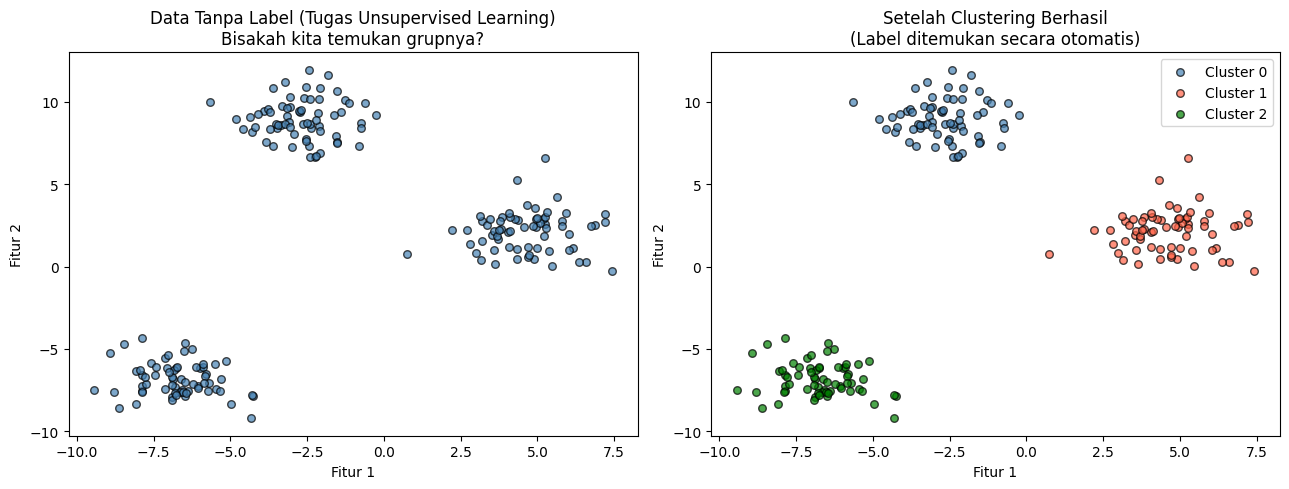

In [2]:
# Visualisasi motivasi unsupervised learning
from sklearn.datasets import make_blobs

X_demo, y_demo = make_blobs(n_samples=200, centers=3, random_state=42, cluster_std=1.2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Tanpa label (unsupervised: kita tidak tahu warnanya)
axes[0].scatter(X_demo[:, 0], X_demo[:, 1], color="steelblue",
                edgecolors="k", s=30, alpha=0.7)
axes[0].set_title("Data Tanpa Label (Tugas Unsupervised Learning)\nBisakah kita temukan grupnya?")
axes[0].set_xlabel("Fitur 1")
axes[0].set_ylabel("Fitur 2")

# Dengan label (untuk perbandingan)
colors = ["steelblue", "tomato", "green"]
for cls, color in zip(np.unique(y_demo), colors):
    mask = y_demo == cls
    axes[1].scatter(X_demo[mask, 0], X_demo[mask, 1], color=color,
                    edgecolors="k", s=30, alpha=0.7, label=f"Cluster {cls}")
axes[1].set_title("Setelah Clustering Berhasil\n(Label ditemukan secara otomatis)")
axes[1].set_xlabel("Fitur 1")
axes[1].set_ylabel("Fitur 2")
axes[1].legend()

plt.tight_layout()
plt.show()

## 3.2 Preprocessing dan Scaling Fitur

Banyak algoritma ML sensitif terhadap skala fitur. Bayangkan satu fitur bernilai
0-1 dan fitur lain bernilai 0-1000. Algoritma berbasis jarak (kNN, SVM) dan
gradient descent (neural network, logistic regression) akan didominasi fitur
dengan skala besar.

**Aturan emas preprocessing:**
Fit scaler HANYA pada data training, kemudian terapkan transformasi yang sama
pada data test. Jangan pernah fit pada data test karena akan terjadi data leakage.

**Empat scaler utama:**

**StandardScaler**
Mengurangi rata-rata dan membagi dengan standar deviasi.
Hasil: mean=0, std=1. Tidak menjamin rentang tertentu.
Cocok untuk: sebagian besar kasus, terutama jika distribusi mendekati normal.

**MinMaxScaler**
Mengubah skala ke rentang [0, 1] (atau rentang custom).
Formula: (x - min) / (max - min)
Cocok untuk: ketika butuh nilai dalam rentang tetap, image processing.
Kelemahan: sangat sensitif terhadap outlier.

**RobustScaler**
Menggunakan median dan IQR (interquartile range) bukan mean dan std.
Sangat robust terhadap outlier.
Cocok untuk: data dengan banyak outlier.

**Normalizer**
Menormalisasi setiap baris (sampel) ke panjang unit (L2 norm = 1).
Cocok untuk: data teks, frekuensi kemunculan kata.

In [3]:
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler, Normalizer
)

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, random_state=0)

# Statistik SEBELUM scaling (3 fitur pertama)
print("=== Statistik Fitur SEBELUM Scaling (3 fitur pertama) ===")
print(f"{'Fitur':<35} {'Min':>8} {'Max':>10} {'Mean':>10} {'Std':>10}")
print("-" * 75)
for i, name in enumerate(cancer.feature_names[:3]):
    col = X_train[:, i]
    print(f"{name:<35} {col.min():>8.3f} {col.max():>10.3f} "
          f"{col.mean():>10.3f} {col.std():>10.3f}")

=== Statistik Fitur SEBELUM Scaling (3 fitur pertama) ===
Fitur                                    Min        Max       Mean        Std
---------------------------------------------------------------------------
mean radius                            6.981     28.110     14.159      3.548
mean texture                           9.710     33.810     19.233      4.118
mean perimeter                        43.790    188.500     92.144     24.409


In [4]:
# Terapkan semua scaler dan bandingkan
scalers = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler":   MinMaxScaler(),
    "RobustScaler":   RobustScaler(),
}

print("=== Statistik Fitur SETELAH Scaling (fitur pertama) ===")
for sc_name, scaler in scalers.items():
    # FIT hanya pada training data
    X_tr_sc = scaler.fit_transform(X_train)
    # TRANSFORM test data menggunakan parameter dari training
    X_te_sc = scaler.transform(X_test)

    col = X_tr_sc[:, 0]
    print(f"{sc_name}:")
    print(f"  Train -- min={col.min():.4f}  max={col.max():.4f}  "
          f"mean={col.mean():.4f}  std={col.std():.4f}")
    col_te = X_te_sc[:, 0]
    print(f"  Test  -- min={col_te.min():.4f}  max={col_te.max():.4f}  "
          f"mean={col_te.mean():.4f}  std={col_te.std():.4f}")
    print()

=== Statistik Fitur SETELAH Scaling (fitur pertama) ===
StandardScaler:
  Train -- min=-2.0230  max=3.9318  mean=-0.0000  std=1.0000
  Test  -- min=-1.8122  max=2.5508  mean=-0.0358  std=0.9686

MinMaxScaler:
  Train -- min=0.0000  max=1.0000  mean=0.3397  std=0.1679
  Test  -- min=0.0354  max=0.7681  mean=0.3337  std=0.1627

RobustScaler:
  Train -- min=-1.5856  max=3.6541  mean=0.1945  std=0.8799
  Test  -- min=-1.4001  max=2.4389  mean=0.1630  std=0.8523



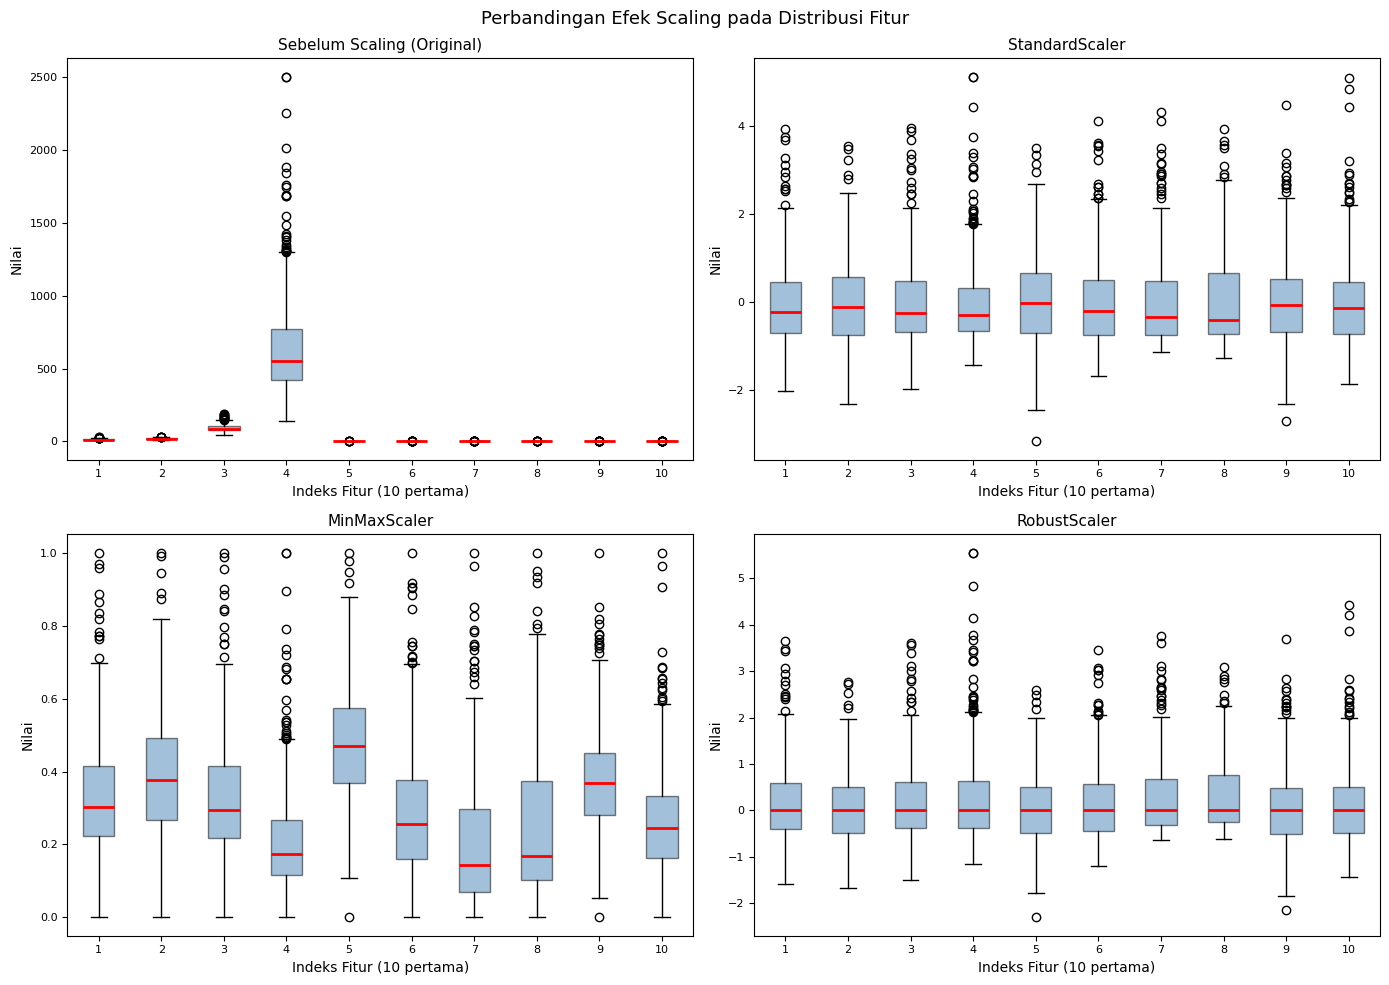

In [5]:
# Visualisasi efek scaling pada distribusi fitur
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

datasets_to_plot = [
    ("Sebelum Scaling (Original)", X_train),
    ("StandardScaler",             StandardScaler().fit_transform(X_train)),
    ("MinMaxScaler",               MinMaxScaler().fit_transform(X_train)),
    ("RobustScaler",               RobustScaler().fit_transform(X_train)),
]

for ax, (title, X_sc) in zip(axes.ravel(), datasets_to_plot):
    ax.boxplot(X_sc[:, :10], vert=True, patch_artist=True,
               boxprops=dict(facecolor="steelblue", alpha=0.5),
               medianprops=dict(color="red", linewidth=2))
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Indeks Fitur (10 pertama)")
    ax.set_ylabel("Nilai")
    ax.tick_params(labelsize=8)

plt.suptitle("Perbandingan Efek Scaling pada Distribusi Fitur", fontsize=13)
plt.tight_layout()
plt.show()

In [6]:
# Demonstrasi pentingnya scaling: kNN dengan dan tanpa scaling
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

# Tanpa scaling
knn.fit(X_train, y_train)
acc_no_scale = knn.score(X_test, y_test)

# Dengan StandardScaler
sc = StandardScaler()
X_tr_sc = sc.fit_transform(X_train)
X_te_sc = sc.transform(X_test)
knn.fit(X_tr_sc, y_train)
acc_scaled = knn.score(X_te_sc, y_test)

print("=== Pengaruh Scaling pada kNN (k=5) ===")
print(f"Tanpa scaling  : {acc_no_scale:.4f}")
print(f"Dengan scaling : {acc_scaled:.4f}")
print(f"Peningkatan    : {(acc_scaled - acc_no_scale)*100:.2f}%")
print()
print("Scaling bisa memberikan peningkatan signifikan untuk algoritma berbasis jarak.")

=== Pengaruh Scaling pada kNN (k=5) ===
Tanpa scaling  : 0.9371
Dengan scaling : 0.9510
Peningkatan    : 1.40%

Scaling bisa memberikan peningkatan signifikan untuk algoritma berbasis jarak.


## 3.3 Principal Component Analysis (PCA)

PCA adalah teknik reduksi dimensi yang paling banyak digunakan.
Ia menemukan arah-arah dengan variansi terbesar dalam data (principal components)
dan memproyeksikan data ke subspace berdimensi lebih rendah.

**Langkah-langkah PCA:**
1. Pusatkan data (kurangi rata-rata setiap fitur)
2. Hitung matriks kovariansi
3. Cari eigenvector dan eigenvalue matriks kovariansi
4. Urutkan eigenvector berdasarkan eigenvalue (terbesar = variansi terbesar)
5. Proyeksikan data ke k eigenvector teratas

**Interpretasi:**
- Setiap principal component adalah kombinasi linear dari fitur asli
- PC1 menjelaskan variansi terbesar, PC2 terbesar kedua (tegak lurus PC1), dst
- Explained variance ratio menunjukkan berapa persen variansi data dijelaskan setiap PC

**Kegunaan PCA:**
- Visualisasi data berdimensi tinggi (reduksi ke 2D atau 3D)
- Menghilangkan noise (komponen dengan variansi kecil biasanya noise)
- Mempercepat algoritma downstream dengan mengurangi jumlah fitur
- Mengatasi multikolinearitas

**Keterbatasan PCA:**
- Komponen adalah kombinasi linear semua fitur, sulit diinterpretasi
- Hanya menangkap hubungan linear antar fitur
- Tidak cocok untuk data yang punya struktur non-linear kompleks

In [7]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

cancer = load_breast_cancer()

# Scaling dulu sebelum PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cancer.data)

# PCA 2 komponen untuk visualisasi
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("=== PCA pada Breast Cancer Dataset ===")
print(f"Shape asli   : {cancer.data.shape}")
print(f"Shape setelah PCA: {X_pca.shape}")
print()
print("Explained variance ratio per komponen:")
for i, evr in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {evr:.4f} ({evr*100:.2f}%)")
print(f"Total variansi dijelaskan: {pca.explained_variance_ratio_.sum()*100:.2f}%")

=== PCA pada Breast Cancer Dataset ===
Shape asli   : (569, 30)
Shape setelah PCA: (569, 2)

Explained variance ratio per komponen:
  PC1: 0.4427 (44.27%)
  PC2: 0.1897 (18.97%)
Total variansi dijelaskan: 63.24%


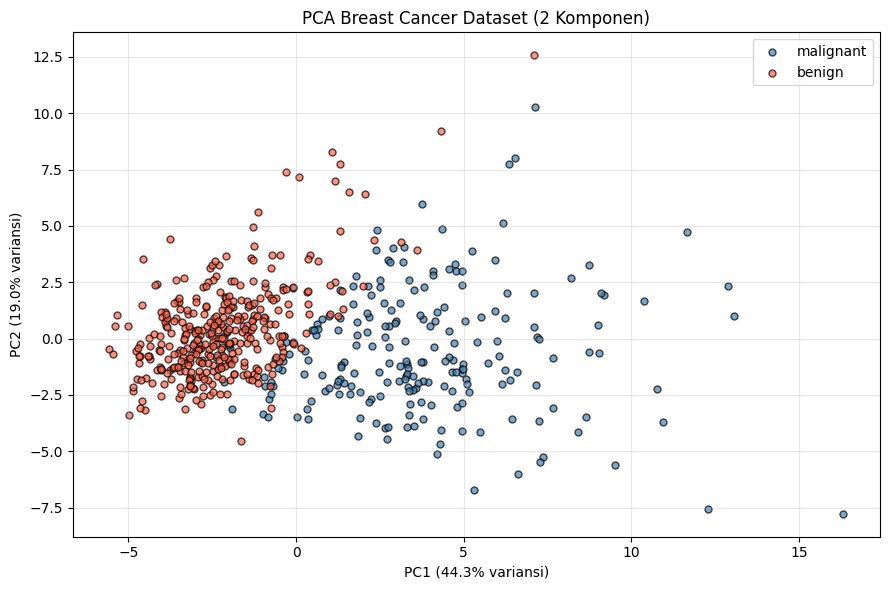

PCA 2D sudah cukup memisahkan kedua kelas dengan jelas.


In [8]:
# Visualisasi PCA 2D
plt.figure(figsize=(9, 6))
colors = ["steelblue", "tomato"]
for cls, color, name in zip([0, 1], colors, cancer.target_names):
    mask = cancer.target == cls
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=name,
                edgecolors="k", s=25, alpha=0.7)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variansi)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variansi)")
plt.title("PCA Breast Cancer Dataset (2 Komponen)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("PCA 2D sudah cukup memisahkan kedua kelas dengan jelas.")

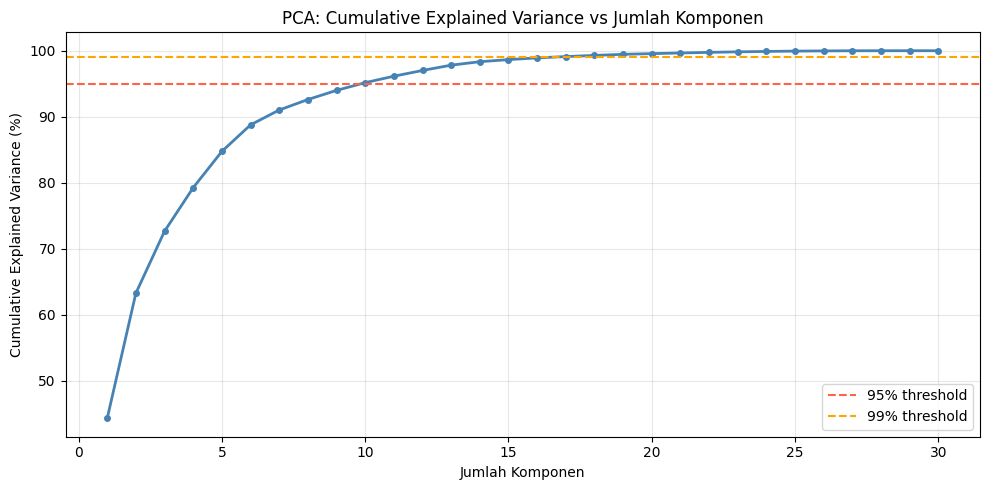

Komponen untuk 95% variansi: 10 dari 30
Komponen untuk 99% variansi: 17 dari 30
Reduksi dimensi 95%: dari 30 ke 10 fitur


In [9]:
# Berapa komponen yang diperlukan untuk menjelaskan 95% variansi?
pca_full = PCA()
pca_full.fit(X_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumvar) + 1), cumvar * 100,
         marker="o", markersize=4, linewidth=2, color="steelblue")
plt.axhline(95, color="tomato", linestyle="--", linewidth=1.5, label="95% threshold")
plt.axhline(99, color="orange", linestyle="--", linewidth=1.5, label="99% threshold")
plt.xlabel("Jumlah Komponen")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("PCA: Cumulative Explained Variance vs Jumlah Komponen")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

n_95 = np.searchsorted(cumvar, 0.95) + 1
n_99 = np.searchsorted(cumvar, 0.99) + 1
print(f"Komponen untuk 95% variansi: {n_95} dari {cancer.data.shape[1]}")
print(f"Komponen untuk 99% variansi: {n_99} dari {cancer.data.shape[1]}")
print(f"Reduksi dimensi 95%: dari {cancer.data.shape[1]} ke {n_95} fitur")

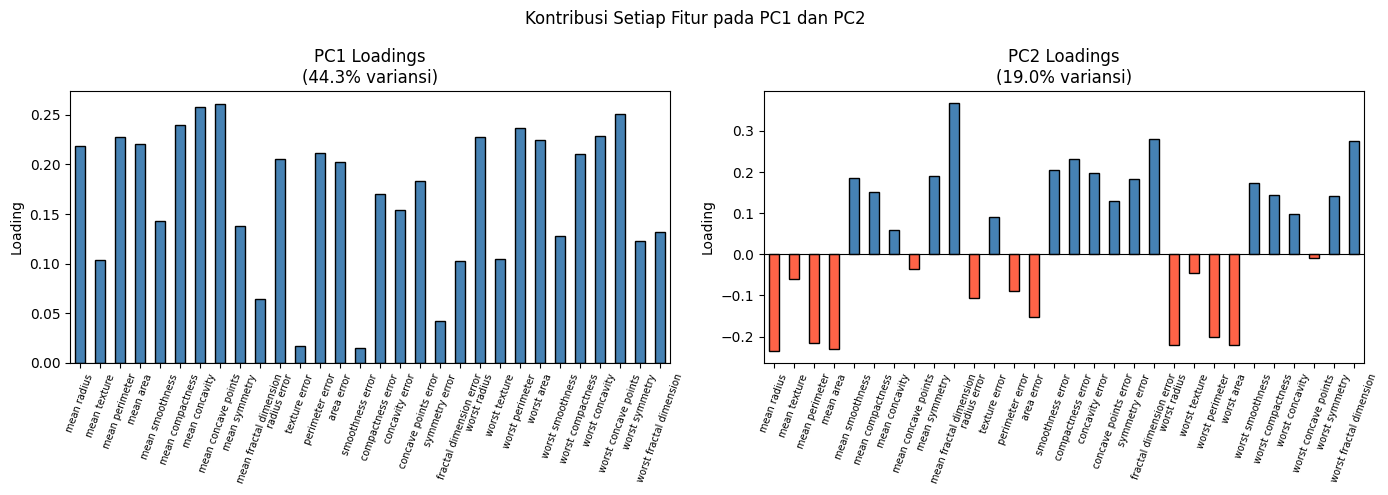

Fitur dengan loading besar (absolut) berkontribusi paling besar pada PC tersebut.


In [10]:
# Visualisasi komponen PCA (loadings) -- fitur mana yang paling berkontribusi
pca2 = PCA(n_components=2)
pca2.fit(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, ax in enumerate(axes):
    loading = pd.Series(pca2.components_[i], index=cancer.feature_names)
    loading.plot(kind="bar", ax=ax,
                 color=["steelblue" if v > 0 else "tomato" for v in loading],
                 edgecolor="black")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"PC{i+1} Loadings\n({pca2.explained_variance_ratio_[i]*100:.1f}% variansi)")
    ax.set_ylabel("Loading")
    ax.tick_params(axis="x", rotation=70, labelsize=7)

plt.suptitle("Kontribusi Setiap Fitur pada PC1 dan PC2", fontsize=12)
plt.tight_layout()
plt.show()
print("Fitur dengan loading besar (absolut) berkontribusi paling besar pada PC tersebut.")

## 3.4 Non-Negative Matrix Factorization (NMF)

NMF menguraikan matriks data X menjadi dua matriks non-negatif W dan H:

    X (n_samples x n_features) = W (n_samples x k) x H (k x n_features)

di mana semua nilai dalam W, H, dan X harus non-negatif.

**Perbedaan utama dengan PCA:**
- PCA: komponen bisa bernilai negatif, sulit diinterpretasi secara fisik
- NMF: semua nilai non-negatif, menghasilkan representasi "parts-based"
  yang lebih mudah diinterpretasi

**Representasi "parts-based":**
Karena tidak ada nilai negatif, setiap fitur di output adalah kombinasi
penambahan (additive) dari komponen-komponen. Ini mirip bagaimana manusia
mengenali wajah dari bagian-bagiannya (mata, hidung, mulut).

**Syarat:** data input harus non-negatif. Cocok untuk:
- Gambar (pixel values >= 0)
- Teks (word counts >= 0)
- Data audio (spektrum frekuensi >= 0)

**Keterbatasan:**
- Tidak ada jaminan komponen yang ditemukan unik (inisialisasi berbeda bisa hasil berbeda)
- Tidak menjamin variansi yang dijelaskan seperti PCA

In [11]:
from sklearn.decomposition import NMF

# NMF pada dataset digits (pixel values non-negatif)
digits = load_digits()
X_digits = digits.data / 16.0  # Normalisasi ke [0, 1]

print("=== NMF pada Digits Dataset ===")
print(f"Shape data: {X_digits.shape}")
print(f"Range nilai: [{X_digits.min():.2f}, {X_digits.max():.2f}]")
print()

nmf = NMF(n_components=15, random_state=0, max_iter=1000)
W = nmf.fit_transform(X_digits)
H = nmf.components_

print(f"Matriks W (koefisien)  shape: {W.shape}")
print(f"Matriks H (komponen)   shape: {H.shape}")
print(f"Rekonstruksi error: {nmf.reconstruction_err_:.4f}")

=== NMF pada Digits Dataset ===
Shape data: (1797, 64)
Range nilai: [0.00, 1.00]

Matriks W (koefisien)  shape: (1797, 15)
Matriks H (komponen)   shape: (15, 64)
Rekonstruksi error: 43.6988


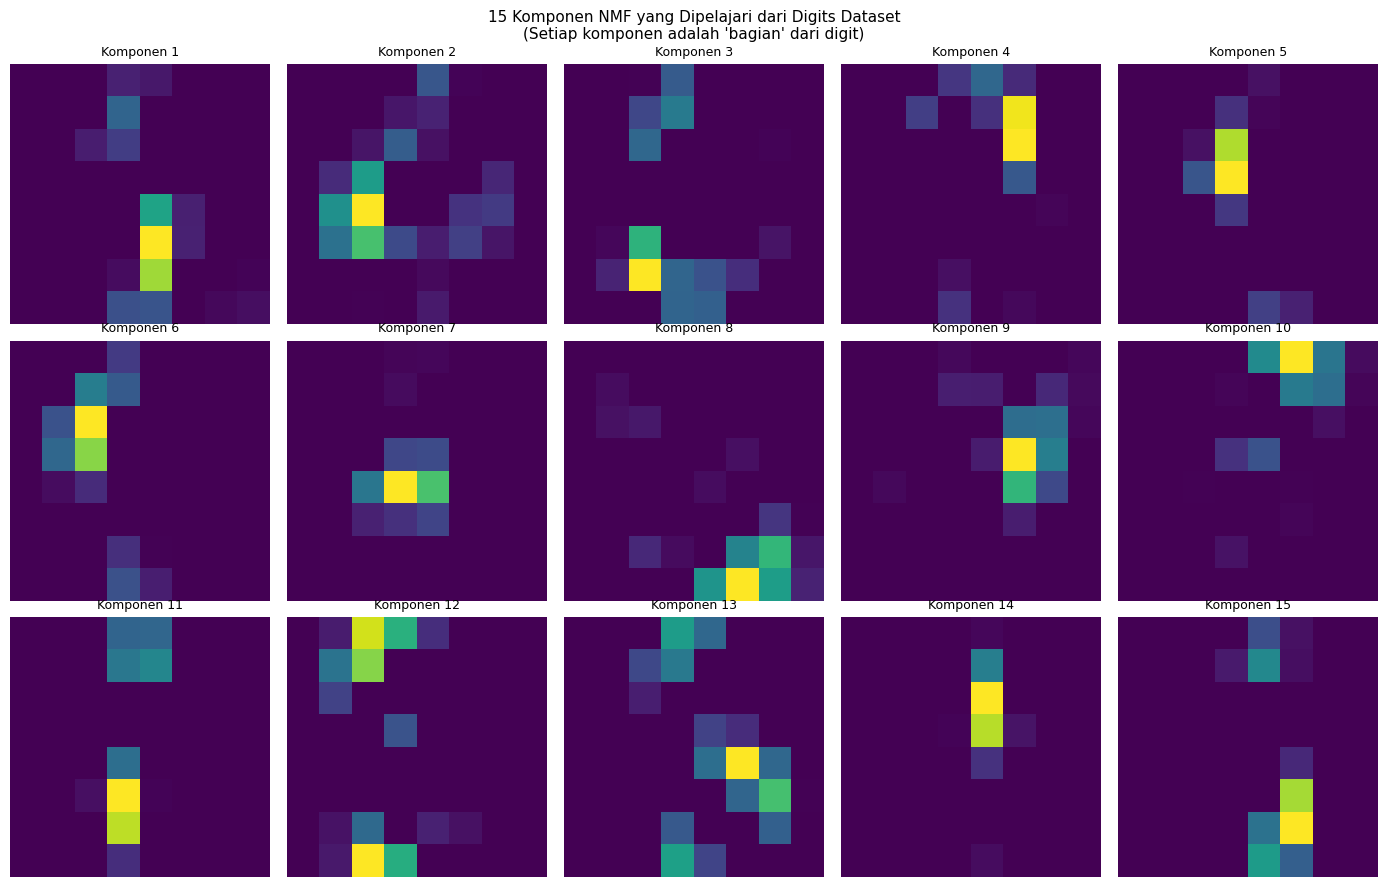

In [12]:
# Visualisasi 15 komponen NMF yang dipelajari
fig, axes = plt.subplots(3, 5, figsize=(14, 9))
for i, (ax, comp) in enumerate(zip(axes.ravel(), H)):
    ax.imshow(comp.reshape(8, 8), cmap="viridis", interpolation="nearest")
    ax.set_title(f"Komponen {i+1}", fontsize=9)
    ax.axis("off")

plt.suptitle("15 Komponen NMF yang Dipelajari dari Digits Dataset\n"
             "(Setiap komponen adalah 'bagian' dari digit)", fontsize=11)
plt.tight_layout()
plt.show()

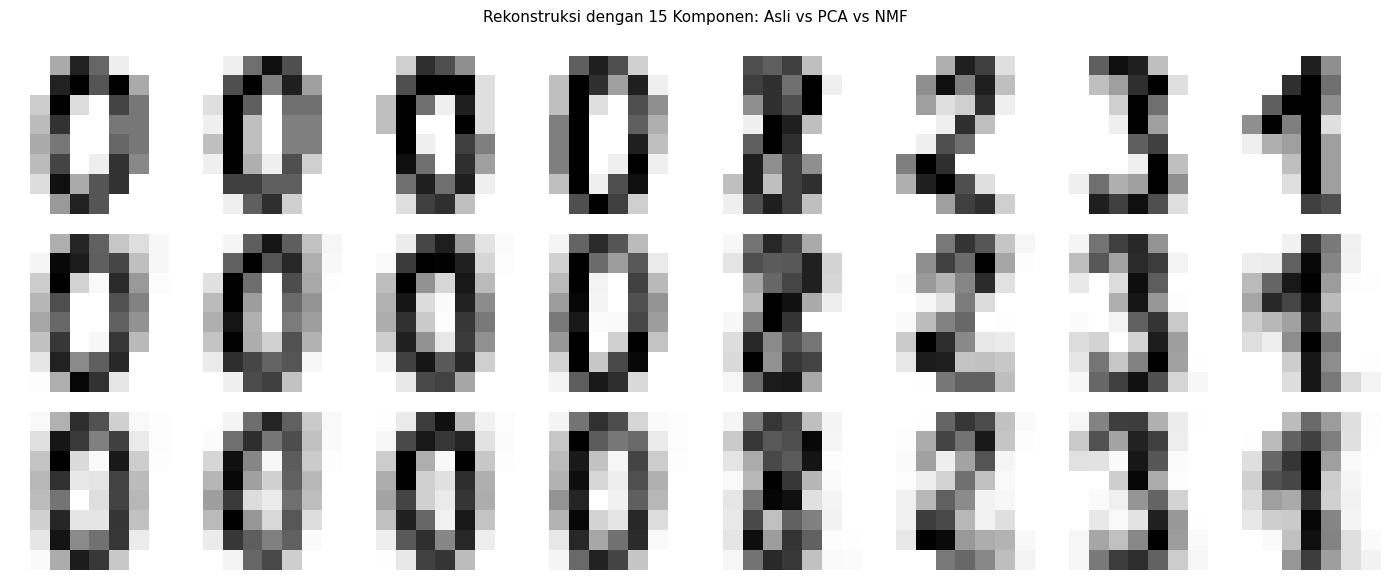

In [13]:
# Bandingkan rekonstruksi PCA vs NMF
from sklearn.decomposition import PCA

n_comp = 15

# PCA (perlu geser ke non-negatif untuk visualisasi)
pca_d = PCA(n_components=n_comp)
W_pca = pca_d.fit_transform(X_digits)

# Rekonstruksi
X_recon_nmf = W.dot(H)
X_recon_pca = pca_d.inverse_transform(W_pca)
X_recon_pca = np.clip(X_recon_pca, 0, 1)  # Clip ke [0,1]

# Tampilkan beberapa sampel asli vs rekonstruksi
fig, axes = plt.subplots(3, 8, figsize=(14, 6))
sample_idx = [0, 10, 20, 30, 40, 50, 60, 70]

for col, idx in enumerate(sample_idx):
    axes[0, col].imshow(X_digits[idx].reshape(8, 8), cmap="gray_r")
    axes[0, col].axis("off")
    if col == 0:
        axes[0, col].set_ylabel("Asli", fontsize=9)

    axes[1, col].imshow(X_recon_pca[idx].reshape(8, 8), cmap="gray_r")
    axes[1, col].axis("off")
    if col == 0:
        axes[1, col].set_ylabel("PCA", fontsize=9)

    axes[2, col].imshow(X_recon_nmf[idx].reshape(8, 8), cmap="gray_r")
    axes[2, col].axis("off")
    if col == 0:
        axes[2, col].set_ylabel("NMF", fontsize=9)

plt.suptitle(f"Rekonstruksi dengan {n_comp} Komponen: Asli vs PCA vs NMF", fontsize=11)
plt.tight_layout()
plt.show()

## 3.5 Manifold Learning: t-SNE

t-SNE (t-distributed Stochastic Neighbor Embedding) adalah algoritma reduksi
dimensi non-linear yang dirancang khusus untuk visualisasi.

**Ide utama t-SNE:**
Pertahankan struktur neighborhood data. Titik-titik yang dekat di dimensi tinggi
harus tetap dekat di representasi 2D, dan titik-titik yang jauh harus tetap jauh.

**Cara kerja (sederhana):**
1. Hitung distribusi probabilitas pasangan titik di dimensi tinggi (Gaussian)
2. Definisikan distribusi probabilitas di dimensi rendah (Student t-distribution)
3. Minimisasi KL divergence antara dua distribusi
4. t-distribution di langkah 2 menghasilkan "pemisahan" yang lebih baik

**Mengapa t-distribution bukan Gaussian di dimensi rendah?**
t-distribution punya ekor yang lebih tebal, sehingga titik-titik yang agak jauh
mendapat probabilitas rendah dan "didorong" lebih jauh lagi. Ini menghasilkan
cluster yang lebih terbuka dan terpisah secara visual.

**Sifat-sifat t-SNE yang penting:**
- HANYA untuk visualisasi, tidak bisa digunakan sebagai preprocessing
- Tidak bisa mentransformasi data baru (harus fit ulang)
- Hasil bergantung pada hyperparameter `perplexity` (biasanya 5-50)
- Komputasi mahal untuk dataset besar
- Jarak antar cluster tidak bermakna (hanya posisi relatif yang bermakna)

In [14]:
from sklearn.manifold import TSNE

digits = load_digits()

print("Menjalankan t-SNE pada Digits Dataset (1797 sampel, 64 fitur)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30,
             n_iter=1000, learning_rate="auto", init="pca")
X_tsne = tsne.fit_transform(digits.data)

print(f"Shape hasil t-SNE: {X_tsne.shape}")
print(f"KL divergence akhir: {tsne.kl_divergence_:.4f}")

Menjalankan t-SNE pada Digits Dataset (1797 sampel, 64 fitur)...
Shape hasil t-SNE: (1797, 2)
KL divergence akhir: 0.7544


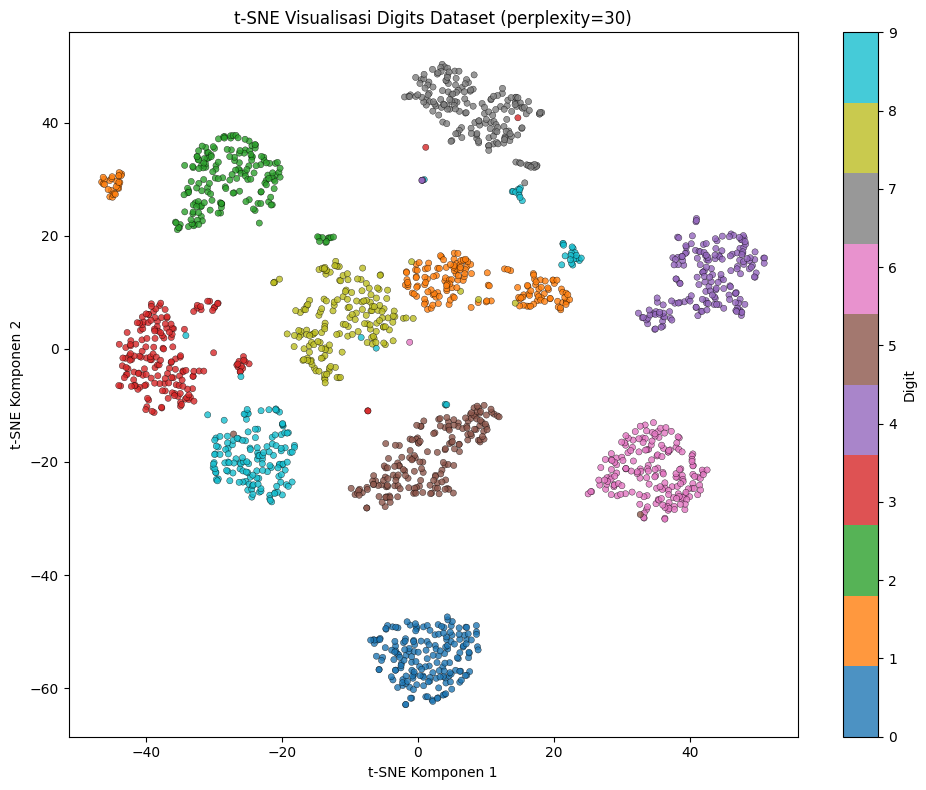

t-SNE berhasil memisahkan 10 digit ke dalam cluster yang berbeda.
Cluster yang berdekatan biasanya digit yang bentuknya mirip (misal 3 dan 8).


In [15]:
# Visualisasi t-SNE dengan label digit
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1],
                       c=digits.target, cmap="tab10",
                       edgecolors="k", s=20, alpha=0.8, linewidths=0.3)
cbar = plt.colorbar(scatter, ticks=range(10))
cbar.set_label("Digit")
cbar.set_ticklabels([str(i) for i in range(10)])
plt.title("t-SNE Visualisasi Digits Dataset (perplexity=30)")
plt.xlabel("t-SNE Komponen 1")
plt.ylabel("t-SNE Komponen 2")
plt.tight_layout()
plt.show()
print("t-SNE berhasil memisahkan 10 digit ke dalam cluster yang berbeda.")
print("Cluster yang berdekatan biasanya digit yang bentuknya mirip (misal 3 dan 8).")

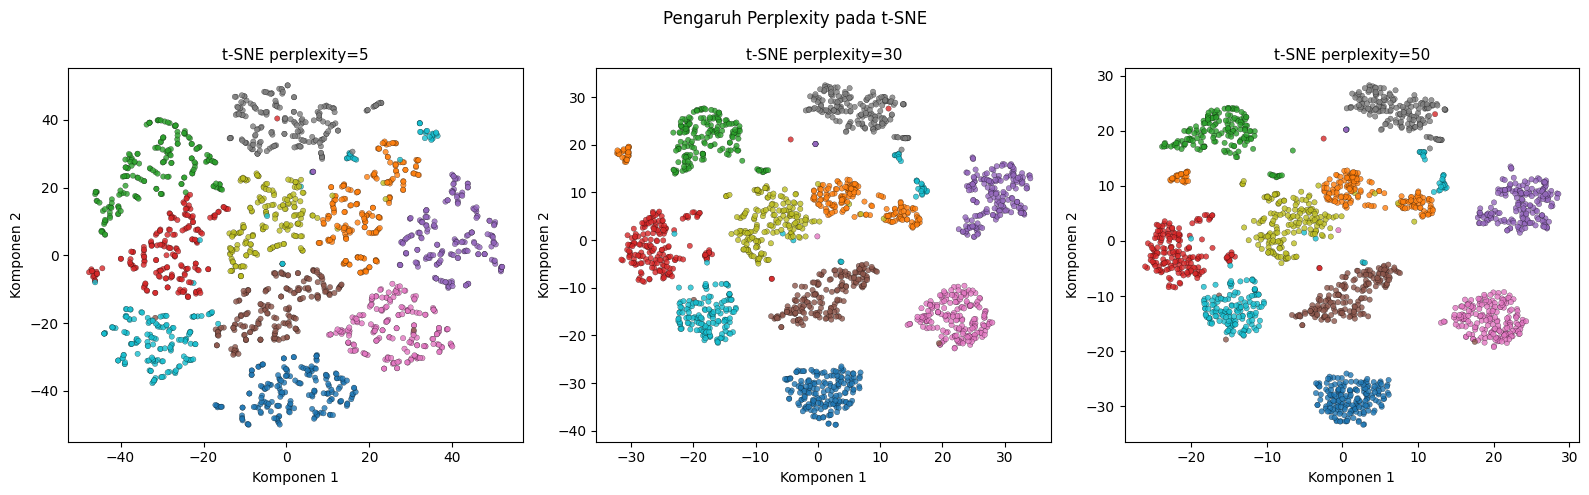

Perplexity kecil: cluster lebih terpecah-pecah.
Perplexity besar: lebih mempertimbangkan struktur global.


In [16]:
# Pengaruh perplexity pada t-SNE
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
perplexities = [5, 30, 50]

for ax, perp in zip(axes, perplexities):
    tsne_p = TSNE(n_components=2, random_state=42, perplexity=perp,
                   n_iter=500, learning_rate="auto", init="pca")
    X_p = tsne_p.fit_transform(digits.data)
    scatter = ax.scatter(X_p[:, 0], X_p[:, 1], c=digits.target,
                          cmap="tab10", edgecolors="k", s=15, alpha=0.8, linewidths=0.2)
    ax.set_title(f"t-SNE perplexity={perp}", fontsize=11)
    ax.set_xlabel("Komponen 1")
    ax.set_ylabel("Komponen 2")

plt.suptitle("Pengaruh Perplexity pada t-SNE", fontsize=12)
plt.tight_layout()
plt.show()
print("Perplexity kecil: cluster lebih terpecah-pecah.")
print("Perplexity besar: lebih mempertimbangkan struktur global.")

## 3.6 k-Means Clustering

k-Means adalah algoritma clustering paling populer dan paling mudah dipahami.

**Algoritma k-Means:**
1. Inisialisasi k centroid secara acak (atau dengan metode k-Means++ yang lebih cerdas)
2. Assign setiap titik data ke centroid terdekat (membentuk k cluster)
3. Perbarui posisi setiap centroid menjadi rata-rata semua titik di clusternya
4. Ulangi langkah 2-3 hingga centroid tidak berubah (konvergen)

**Objektif k-Means:**
Meminimalkan total within-cluster sum of squares (WCSS / inertia):

    inertia = sum_k sum_{x in cluster_k} ||x - centroid_k||^2

**Keunggulan k-Means:**
- Sederhana dan mudah diimplementasi
- Skalabel untuk dataset besar
- Konvergen secara terjamin (meski ke lokal minimum)

**Keterbatasan k-Means:**
- Harus menentukan k di awal
- Mengasumsikan cluster berbentuk bulat (spherical) dan berukuran sama
- Sensitif terhadap inisialisasi (solusi: k-Means++ atau multiple restarts)
- Tidak bisa menemukan cluster berbentuk arbitrer
- Sensitif terhadap outlier

In [17]:
from sklearn.cluster import KMeans

X_cl, y_cl = make_blobs(n_samples=300, centers=4,
                          cluster_std=0.8, random_state=0)

# Fit k-Means dengan k=4
kmeans = KMeans(n_clusters=4, random_state=0, n_init=10)
labels = kmeans.fit_predict(X_cl)

print("=== k-Means Clustering ===")
print(f"k (jumlah cluster)  : 4")
print(f"Inertia (WCSS)      : {kmeans.inertia_:.2f}")
print(f"Iterasi hingga konvergen: {kmeans.n_iter_}")
print(f"Label cluster (unik): {np.unique(labels)}")
print()
print("Distribusi sampel per cluster:")
for cls in np.unique(labels):
    print(f"  Cluster {cls}: {np.sum(labels == cls)} sampel")

=== k-Means Clustering ===
k (jumlah cluster)  : 4
Inertia (WCSS)      : 369.53
Iterasi hingga konvergen: 6
Label cluster (unik): [0 1 2 3]

Distribusi sampel per cluster:
  Cluster 0: 81 sampel
  Cluster 1: 74 sampel
  Cluster 2: 73 sampel
  Cluster 3: 72 sampel


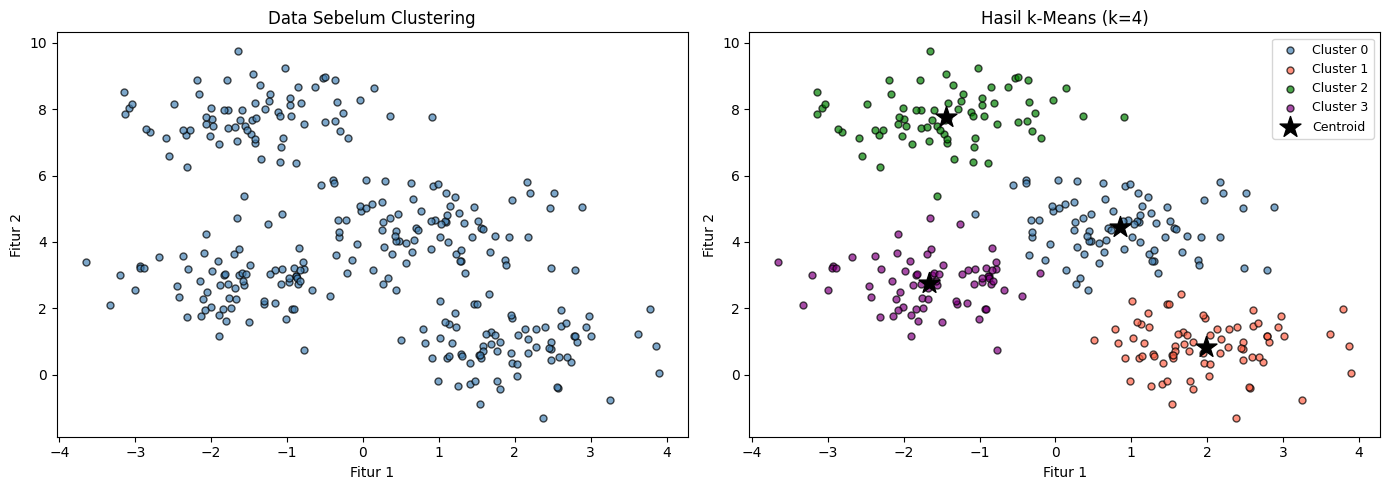

In [18]:
# Visualisasi hasil k-Means
colors_cl = ["steelblue", "tomato", "green", "purple"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Data asli (tanpa label)
axes[0].scatter(X_cl[:, 0], X_cl[:, 1], color="steelblue",
                edgecolors="k", s=25, alpha=0.7)
axes[0].set_title("Data Sebelum Clustering")

# Hasil k-Means
for cls, color in zip(np.unique(labels), colors_cl):
    mask = labels == cls
    axes[1].scatter(X_cl[mask, 0], X_cl[mask, 1], color=color,
                    edgecolors="k", s=25, alpha=0.7, label=f"Cluster {cls}")
axes[1].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                color="black", marker="*", s=250, zorder=5, label="Centroid")
axes[1].set_title("Hasil k-Means (k=4)")
axes[1].legend(fontsize=9)

for ax in axes:
    ax.set_xlabel("Fitur 1")
    ax.set_ylabel("Fitur 2")

plt.tight_layout()
plt.show()

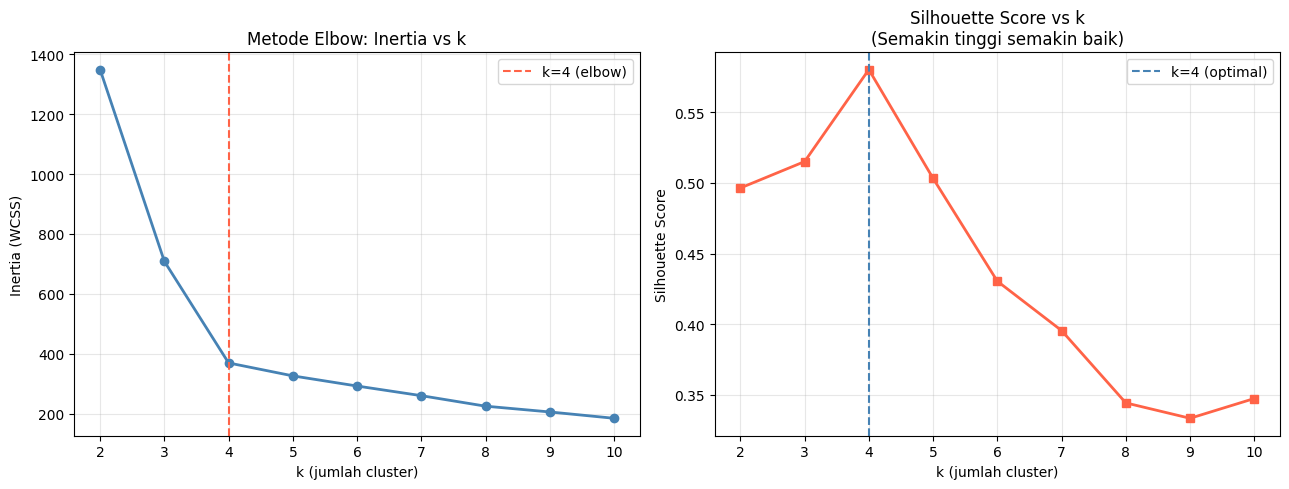

k optimal berdasarkan Silhouette Score: 4


In [19]:
# Metode Elbow untuk memilih k optimal
inertias = []
silhouettes = []
k_range = range(2, 11)

from sklearn.metrics import silhouette_score

for k in k_range:
    km = KMeans(n_clusters=k, random_state=0, n_init=10)
    km.fit(X_cl)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cl, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(k_range, inertias, marker="o", linewidth=2, color="steelblue")
axes[0].set_xlabel("k (jumlah cluster)")
axes[0].set_ylabel("Inertia (WCSS)")
axes[0].set_title("Metode Elbow: Inertia vs k")
axes[0].grid(True, alpha=0.3)
axes[0].axvline(4, color="tomato", linestyle="--", label="k=4 (elbow)")
axes[0].legend()

axes[1].plot(k_range, silhouettes, marker="s", linewidth=2, color="tomato")
axes[1].set_xlabel("k (jumlah cluster)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score vs k\n(Semakin tinggi semakin baik)")
axes[1].grid(True, alpha=0.3)
axes[1].axvline(4, color="steelblue", linestyle="--", label="k=4 (optimal)")
axes[1].legend()

plt.tight_layout()
plt.show()

best_k = list(k_range)[np.argmax(silhouettes)]
print(f"k optimal berdasarkan Silhouette Score: {best_k}")

## 3.7 Agglomerative Clustering (Hierarchical)

Agglomerative clustering adalah metode hierarchical clustering bottom-up.

**Algoritma:**
1. Mulai dengan setiap titik data sebagai cluster tersendiri (n cluster)
2. Hitung jarak antar semua pasangan cluster
3. Gabungkan dua cluster yang paling mirip/dekat
4. Ulangi langkah 2-3 hingga tersisa satu cluster

**Kriteria linkage (cara mengukur jarak antar cluster):**

- **ward**: meminimalkan peningkatan total within-cluster variance. Menghasilkan cluster berukuran serupa. Paling umum digunakan.

- **complete**: jarak cluster = jarak maksimum antara semua pasangan titik dari dua cluster. Menghasilkan cluster kompak.

- **average**: jarak cluster = rata-rata semua jarak pasangan titik dari dua cluster.

- **single**: jarak cluster = jarak minimum antara semua pasangan titik dari dua cluster. Bisa menghasilkan cluster "rantai" (chain-like).

**Keunggulan:**
- Menghasilkan hierarki cluster (dendrogram) yang informatif
- Tidak perlu menentukan k di awal (bisa dipotong di level mana saja)
- Beberapa linkage bisa menangani bentuk cluster non-spherical

**Keterbatasan:**
- Komputasi mahal untuk dataset besar O(n^2) atau O(n^3)
- Tidak bisa mengundo penggabungan yang sudah dilakukan

In [20]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=4, linkage="ward")
agg_labels = agg.fit_predict(X_cl)

print("=== Agglomerative Clustering (ward linkage, k=4) ===")
print("Distribusi sampel per cluster:")
for cls in np.unique(agg_labels):
    print(f"  Cluster {cls}: {np.sum(agg_labels == cls)} sampel")

# Bandingkan dengan k-Means
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(labels, agg_labels)
print(f"\\nAdjusted Rand Index (vs k-Means): {ari:.4f}")
print("ARI mendekati 1 = kedua metode menghasilkan pengelompokan yang sangat mirip.")

=== Agglomerative Clustering (ward linkage, k=4) ===
Distribusi sampel per cluster:
  Cluster 0: 86 sampel
  Cluster 1: 72 sampel
  Cluster 2: 74 sampel
  Cluster 3: 68 sampel
\nAdjusted Rand Index (vs k-Means): 0.9551
ARI mendekati 1 = kedua metode menghasilkan pengelompokan yang sangat mirip.


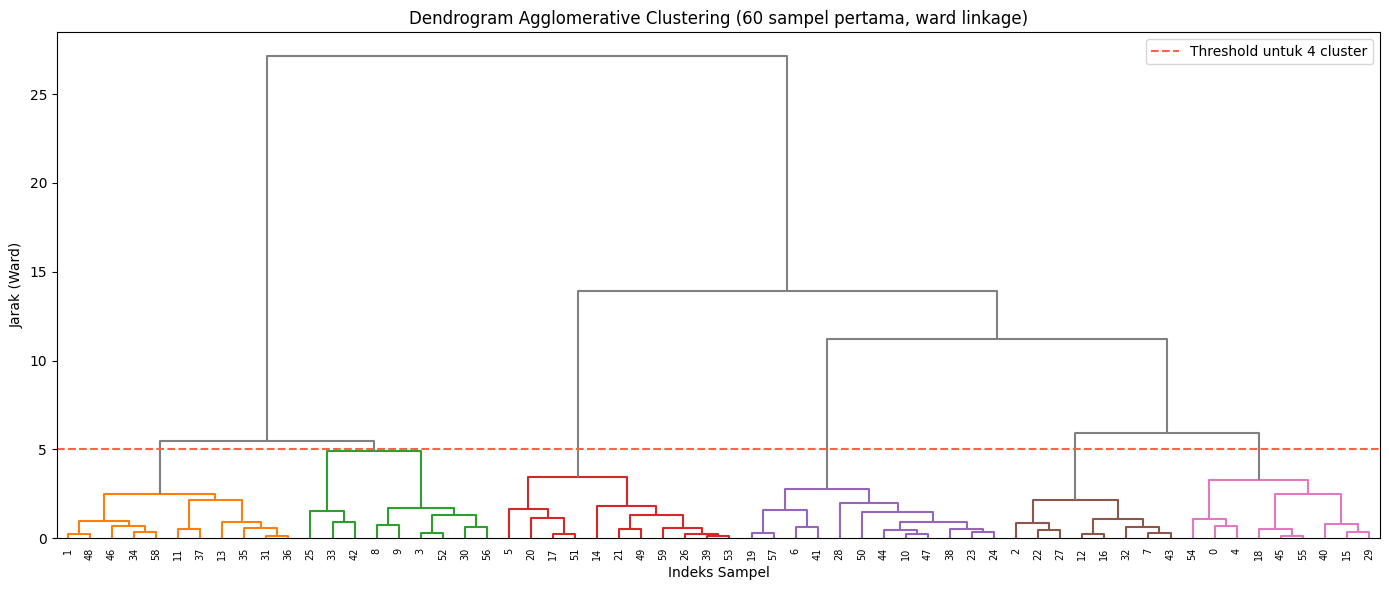

Garis horizontal merah menunjukkan di mana kita 'memotong' pohon
untuk mendapatkan 4 cluster.


In [21]:
# Dendrogram -- visualisasi hierarki cluster
from scipy.cluster.hierarchy import dendrogram, linkage

# Gunakan subset kecil agar dendrogram readable
X_small = X_cl[:60]
Z = linkage(X_small, method="ward")

plt.figure(figsize=(14, 6))
dendrogram(Z, leaf_rotation=90, leaf_font_size=7,
           color_threshold=5,
           above_threshold_color="gray")
plt.title("Dendrogram Agglomerative Clustering (60 sampel pertama, ward linkage)")
plt.xlabel("Indeks Sampel")
plt.ylabel("Jarak (Ward)")
plt.axhline(y=5, color="tomato", linestyle="--",
            label="Threshold untuk 4 cluster")
plt.legend()
plt.tight_layout()
plt.show()
print("Garis horizontal merah menunjukkan di mana kita 'memotong' pohon")
print("untuk mendapatkan 4 cluster.")

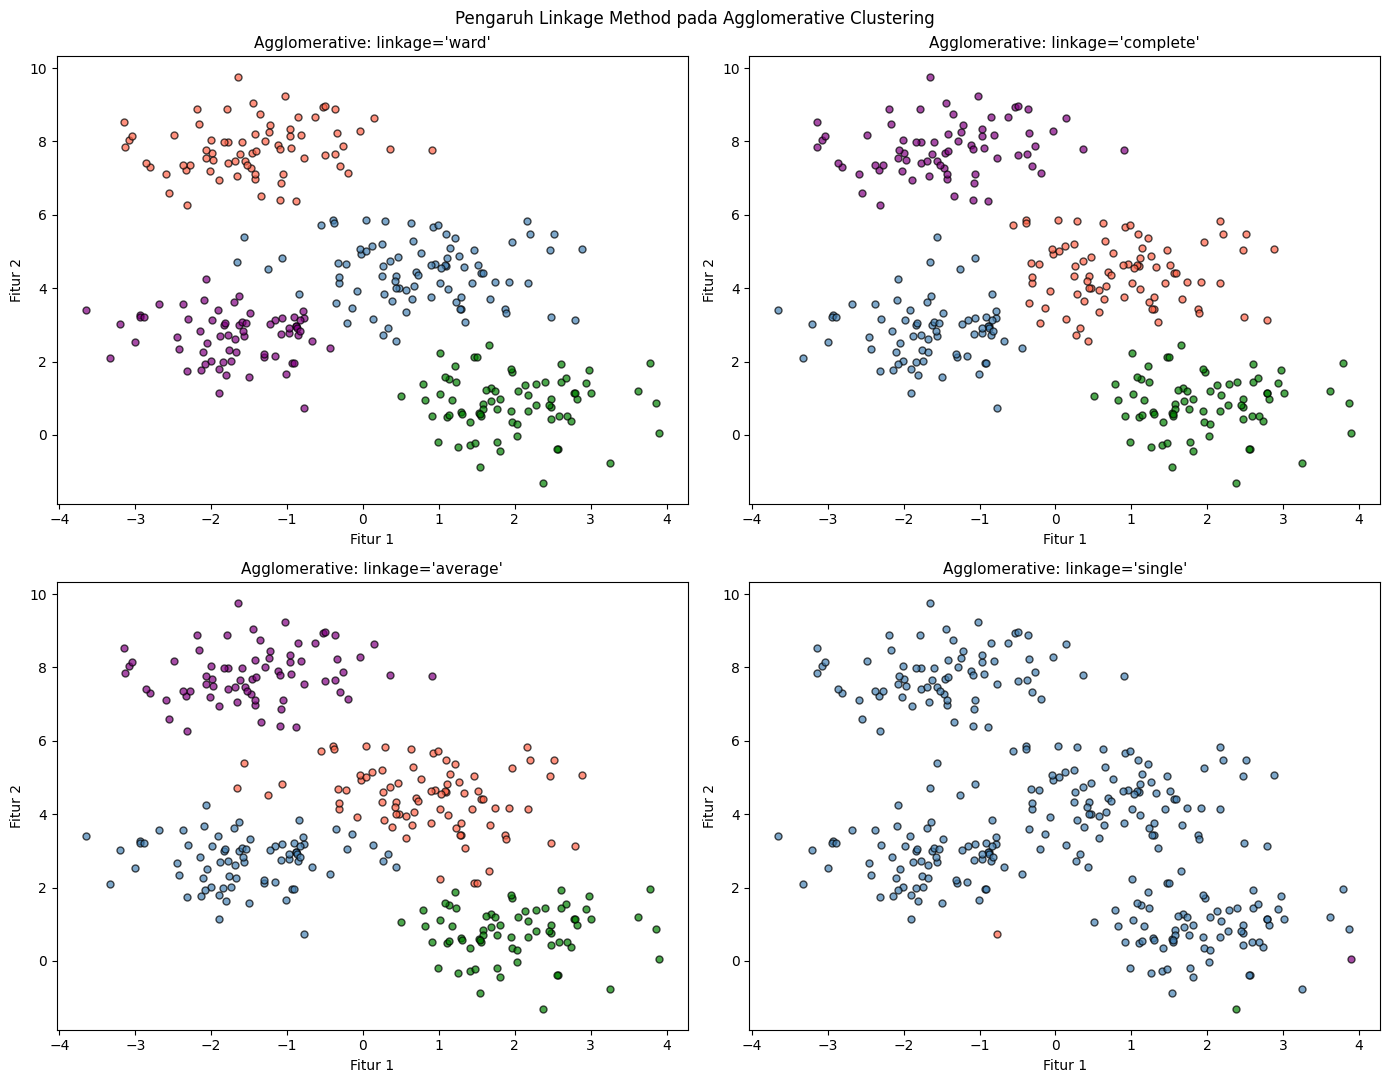

Ward menghasilkan cluster paling seimbang dan kompak.
Single linkage rentan menghasilkan cluster 'rantai' (chaining effect).


In [22]:
# Perbandingan linkage methods
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
linkages = ["ward", "complete", "average", "single"]

for ax, link in zip(axes.ravel(), linkages):
    agg_l = AgglomerativeClustering(n_clusters=4, linkage=link)
    lbl = agg_l.fit_predict(X_cl)
    for cls, color in zip(np.unique(lbl), colors_cl):
        mask = lbl == cls
        ax.scatter(X_cl[mask, 0], X_cl[mask, 1], color=color,
                   edgecolors="k", s=25, alpha=0.7)
    ax.set_title(f"Agglomerative: linkage='{link}'", fontsize=11)
    ax.set_xlabel("Fitur 1")
    ax.set_ylabel("Fitur 2")

plt.suptitle("Pengaruh Linkage Method pada Agglomerative Clustering", fontsize=12)
plt.tight_layout()
plt.show()
print("Ward menghasilkan cluster paling seimbang dan kompak.")
print("Single linkage rentan menghasilkan cluster 'rantai' (chaining effect).")

## 3.8 DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

DBSCAN adalah algoritma clustering berbasis densitas yang tidak memerlukan
spesifikasi jumlah cluster di awal.

**Konsep utama DBSCAN:**

- **Core point**: titik yang memiliki setidaknya `min_samples` tetangga dalam radius `eps`.
  Titik ini dianggap berada di daerah padat.

- **Border point**: titik yang berada dalam radius `eps` dari sebuah core point,
  tapi tidak memenuhi syarat min_samples sendiri. Termasuk dalam cluster core point-nya.

- **Noise point**: titik yang bukan core point dan tidak berada dalam radius `eps`
  dari core point manapun. Dilabeli -1 (outlier/noise).

**Algoritma:**
1. Untuk setiap titik, hitung jumlah tetangga dalam radius eps
2. Tandai titik dengan tetangga >= min_samples sebagai core point
3. Hubungkan semua core point yang saling terhubung (dalam eps satu sama lain)
4. Assign border point ke cluster core point terdekat
5. Titik yang tersisa = noise (label -1)

**Keunggulan DBSCAN:**
- Tidak perlu menentukan k di awal
- Bisa menemukan cluster berbentuk arbitrer (non-spherical)
- Robust terhadap outlier (mengidentifikasi mereka sebagai noise)
- Bisa menemukan cluster dengan densitas berbeda (dengan parameter yang tepat)

**Keterbatasan:**
- Sensitif terhadap pilihan eps dan min_samples
- Kesulitan dengan cluster yang memiliki densitas sangat berbeda
- Performa menurun di dimensi sangat tinggi (curse of dimensionality)

In [23]:
from sklearn.cluster import DBSCAN

# Dataset moons -- DBSCAN ideal untuk bentuk non-spherical
X_db, y_db = make_moons(n_samples=200, noise=0.05, random_state=0)

dbscan = DBSCAN(eps=0.3, min_samples=5)
db_labels = dbscan.fit_predict(X_db)

print("=== DBSCAN pada Moons Dataset ===")
print(f"eps={dbscan.eps}, min_samples={dbscan.min_samples}")
print(f"Label unik yang ditemukan: {np.unique(db_labels)}")
print(f"Jumlah cluster (selain noise): {len(np.unique(db_labels[db_labels != -1]))}")
print(f"Jumlah noise points (-1)      : {np.sum(db_labels == -1)}")
print()
print("Distribusi label:")
for lbl in np.unique(db_labels):
    label_name = "Noise" if lbl == -1 else f"Cluster {lbl}"
    print(f"  {label_name}: {np.sum(db_labels == lbl)} sampel")

=== DBSCAN pada Moons Dataset ===
eps=0.3, min_samples=5
Label unik yang ditemukan: [0 1]
Jumlah cluster (selain noise): 2
Jumlah noise points (-1)      : 0

Distribusi label:
  Cluster 0: 100 sampel
  Cluster 1: 100 sampel


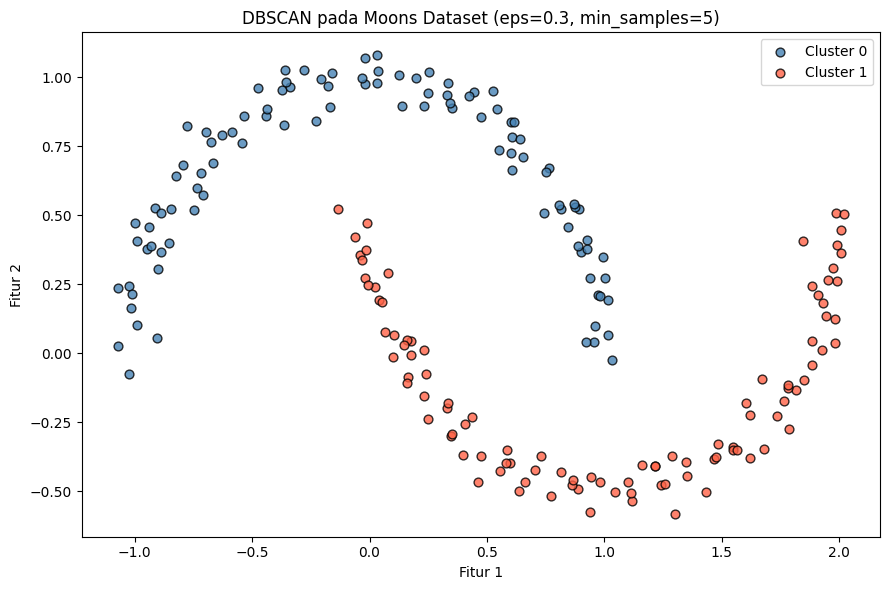

DBSCAN berhasil menemukan 2 cluster berbentuk bulan sabit,
yang tidak bisa ditangkap oleh k-Means.


In [24]:
# Visualisasi DBSCAN
plt.figure(figsize=(9, 6))
unique_labels = np.unique(db_labels)
plot_colors_db = ["steelblue", "tomato", "gray"]

for lbl, color in zip(unique_labels, plot_colors_db):
    mask = db_labels == lbl
    label_name = "Noise" if lbl == -1 else f"Cluster {lbl}"
    marker = "x" if lbl == -1 else "o"
    plt.scatter(X_db[mask, 0], X_db[mask, 1], color=color,
                edgecolors="k" if lbl != -1 else "none",
                marker=marker, s=40, alpha=0.8, label=label_name)

plt.title(f"DBSCAN pada Moons Dataset (eps={dbscan.eps}, min_samples={dbscan.min_samples})")
plt.xlabel("Fitur 1")
plt.ylabel("Fitur 2")
plt.legend()
plt.tight_layout()
plt.show()
print("DBSCAN berhasil menemukan 2 cluster berbentuk bulan sabit,")
print("yang tidak bisa ditangkap oleh k-Means.")

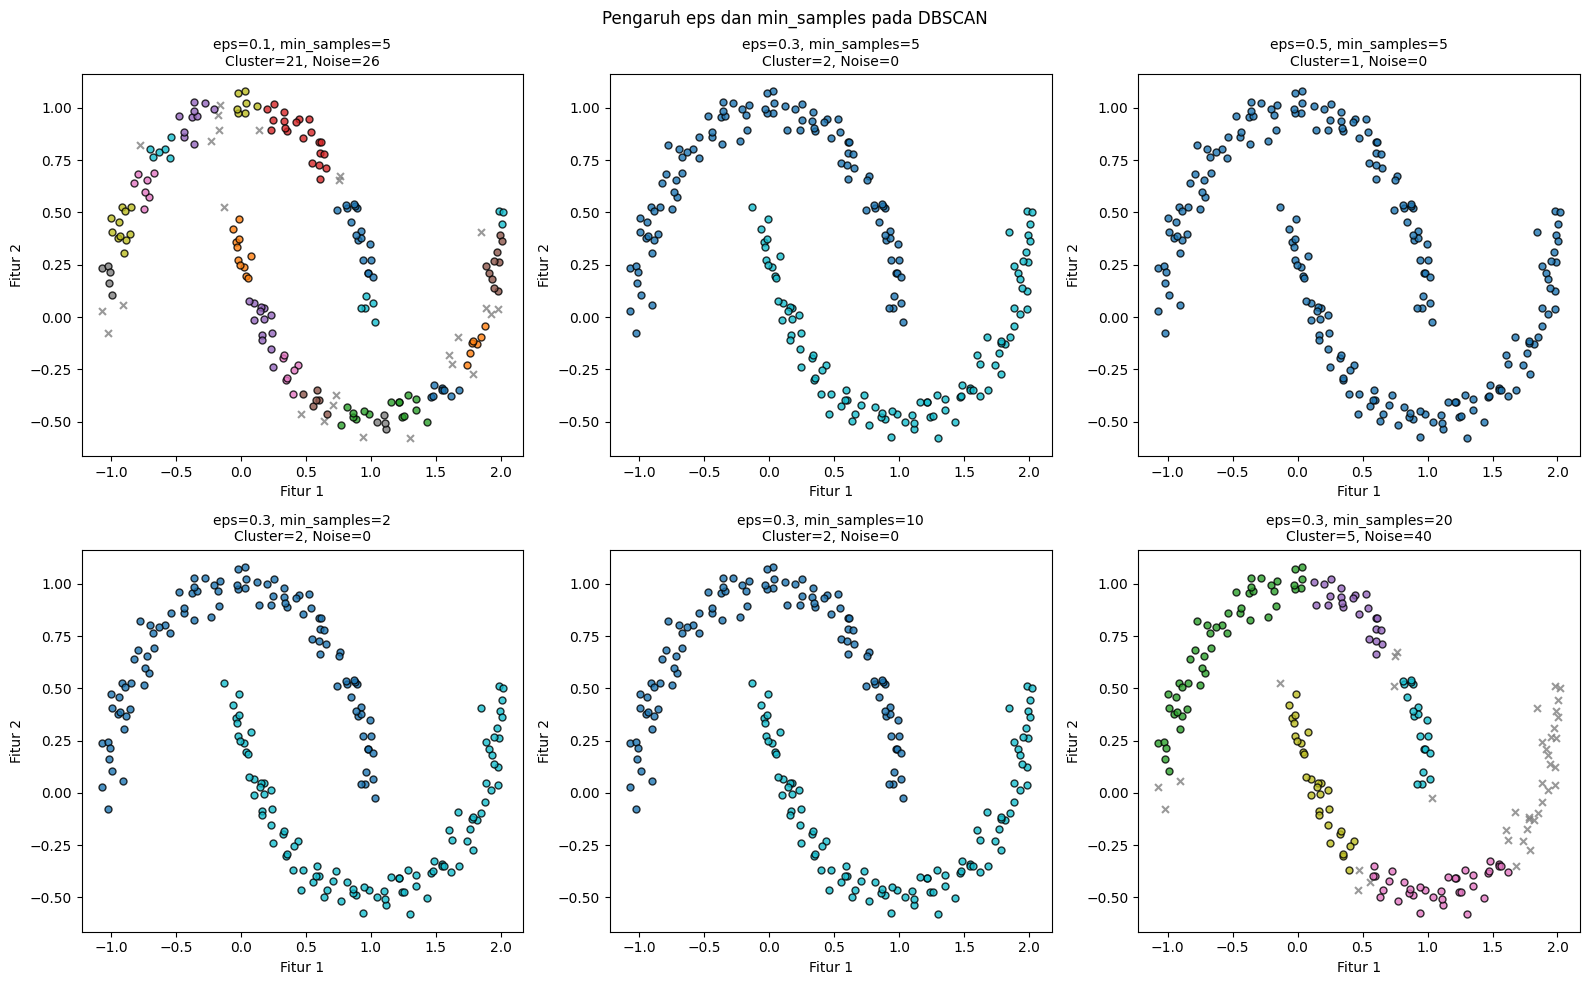

eps terlalu kecil: terlalu banyak noise.
eps terlalu besar: semua titik masuk satu cluster.
min_samples besar: lebih banyak titik dianggap noise.


In [25]:
# Pengaruh eps dan min_samples pada DBSCAN
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
configs = [
    (0.1, 5), (0.3, 5), (0.5, 5),
    (0.3, 2), (0.3, 10), (0.3, 20),
]

for ax, (eps, min_s) in zip(axes.ravel(), configs):
    db = DBSCAN(eps=eps, min_samples=min_s)
    lbl = db.fit_predict(X_db)
    n_clusters = len(np.unique(lbl[lbl != -1]))
    n_noise = np.sum(lbl == -1)

    unique_lbl = np.unique(lbl)
    cmap = plt.cm.get_cmap("tab10", max(len(unique_lbl), 1))
    for i, l in enumerate(unique_lbl):
        mask = lbl == l
        color = "gray" if l == -1 else cmap(i)
        marker = "x" if l == -1 else "o"
        ax.scatter(X_db[mask, 0], X_db[mask, 1], color=color,
                   edgecolors="k" if l != -1 else "none",
                   marker=marker, s=25, alpha=0.8)

    ax.set_title(f"eps={eps}, min_samples={min_s}\n"
                 f"Cluster={n_clusters}, Noise={n_noise}", fontsize=10)
    ax.set_xlabel("Fitur 1")
    ax.set_ylabel("Fitur 2")

plt.suptitle("Pengaruh eps dan min_samples pada DBSCAN", fontsize=12)
plt.tight_layout()
plt.show()
print("eps terlalu kecil: terlalu banyak noise.")
print("eps terlalu besar: semua titik masuk satu cluster.")
print("min_samples besar: lebih banyak titik dianggap noise.")

## 3.9 Perbandingan Algoritma Clustering

Mari kita bandingkan ketiga algoritma clustering pada berbagai bentuk dataset
untuk memahami kekuatan dan kelemahan masing-masing.

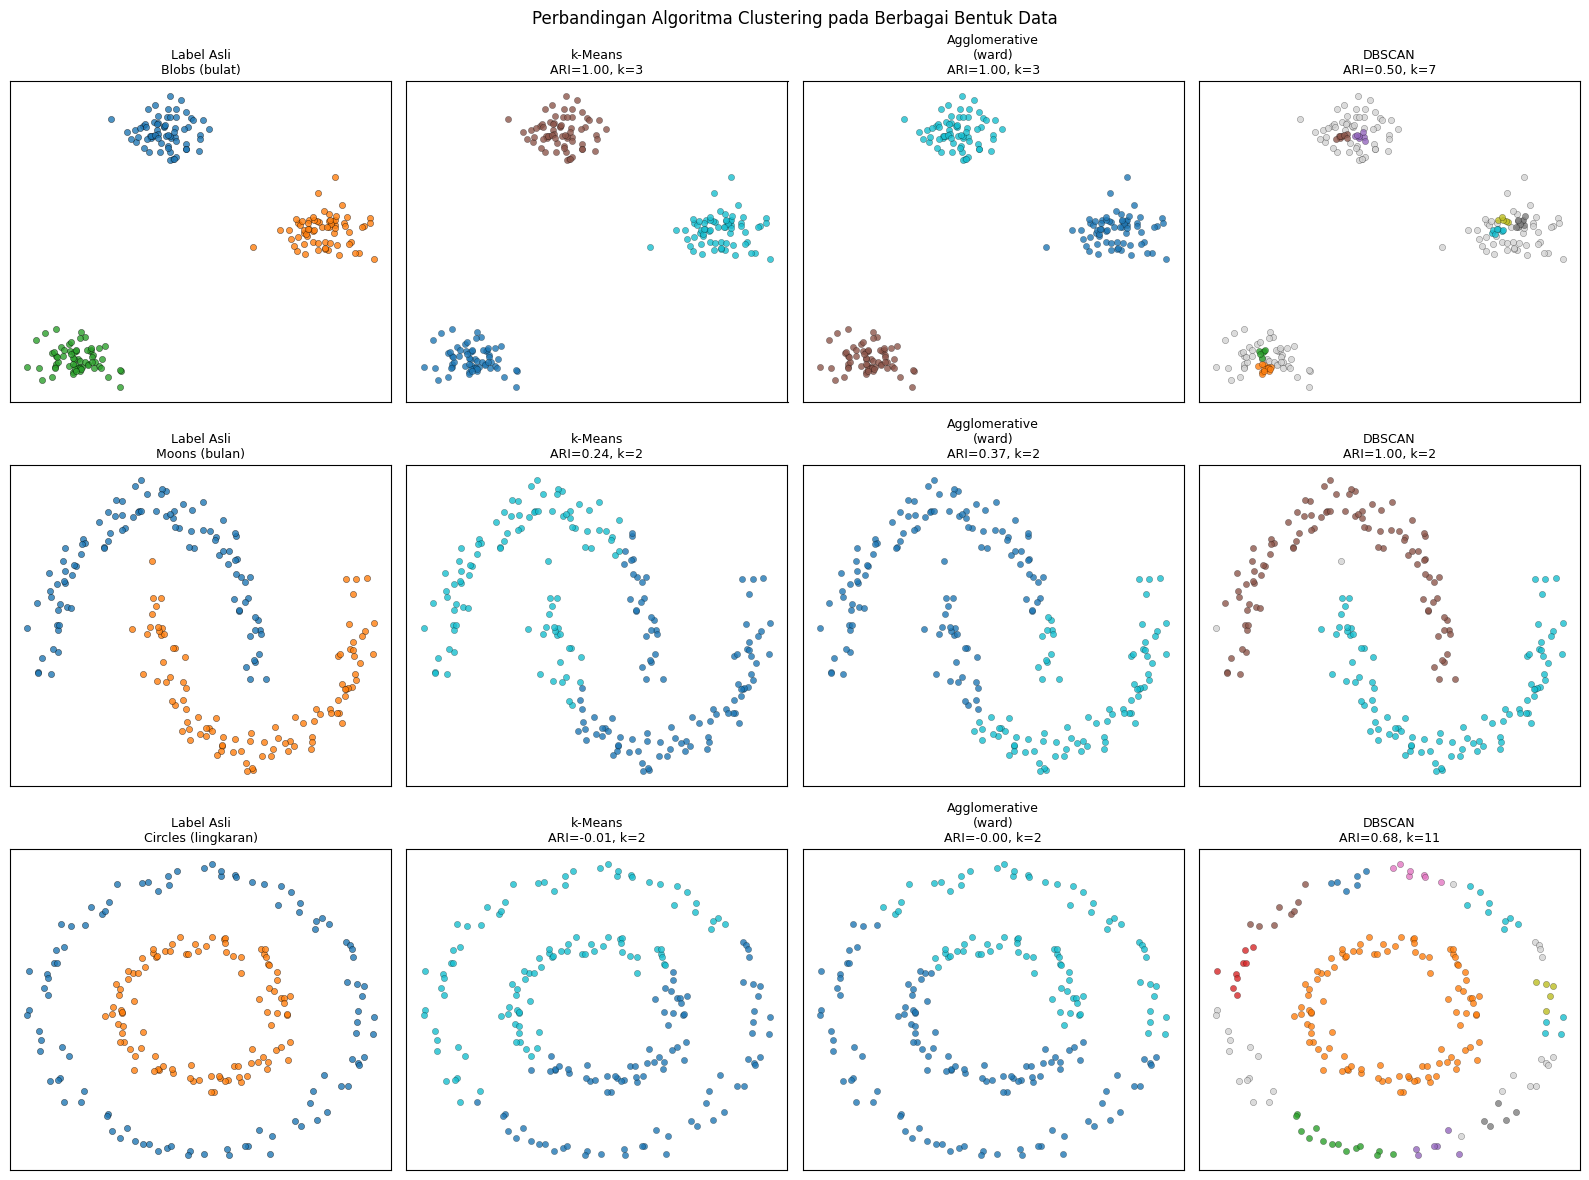

In [26]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.datasets import make_circles

# Buat beberapa dataset dengan bentuk berbeda
X_blobs, y_blobs = make_blobs(n_samples=200, centers=3, random_state=42)
X_moons2, y_moons2 = make_moons(n_samples=200, noise=0.08, random_state=42)
X_circles, y_circles = make_circles(n_samples=200, noise=0.05, factor=0.5, random_state=42)

datasets = [
    ("Blobs (bulat)",    X_blobs,   y_blobs,   3, 0.3, 5),
    ("Moons (bulan)",    X_moons2,  y_moons2,  2, 0.2, 5),
    ("Circles (lingkaran)", X_circles, y_circles, 2, 0.15, 5),
]

algorithms = [
    ("k-Means",        lambda X, k, eps, ms: KMeans(n_clusters=k, random_state=0, n_init=10).fit_predict(X)),
    ("Agglomerative\n(ward)", lambda X, k, eps, ms: AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(X)),
    ("DBSCAN",         lambda X, k, eps, ms: DBSCAN(eps=eps, min_samples=ms).fit_predict(X)),
]

fig, axes = plt.subplots(len(datasets), len(algorithms) + 1,
                          figsize=(16, 12))

for row, (ds_name, X, y_true, k, eps, ms) in enumerate(datasets):
    # Kolom pertama: data asli dengan label benar
    for cls in np.unique(y_true):
        mask = y_true == cls
        axes[row, 0].scatter(X[mask, 0], X[mask, 1], s=20, alpha=0.8,
                              edgecolors="k", linewidths=0.3)
    axes[row, 0].set_title(f"Label Asli\n{ds_name}", fontsize=9)
    axes[row, 0].set_xticks([])
    axes[row, 0].set_yticks([])

    for col, (alg_name, alg_fn) in enumerate(algorithms, start=1):
        lbl = alg_fn(X, k, eps, ms)
        valid = lbl != -1
        n_clusters = len(np.unique(lbl[valid]))

        unique_lbl = np.unique(lbl)
        cmap = plt.cm.get_cmap("tab10", max(len(unique_lbl), 1))
        for i, l in enumerate(unique_lbl):
            mask = lbl == l
            color = "lightgray" if l == -1 else cmap(i)
            axes[row, col].scatter(X[mask, 0], X[mask, 1], color=color,
                                    s=20, alpha=0.8, edgecolors="k", linewidths=0.2)

        # Hitung ARI jika ada cluster valid
        if np.sum(valid) > 0 and n_clusters > 1:
            ari = adjusted_rand_score(y_true[valid], lbl[valid])
            title = f"{alg_name}\nARI={ari:.2f}, k={n_clusters}"
        else:
            title = f"{alg_name}\nGagal"

        axes[row, col].set_title(title, fontsize=9)
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])

plt.suptitle("Perbandingan Algoritma Clustering pada Berbagai Bentuk Data", fontsize=12)
plt.tight_layout()
plt.show()

In [27]:
# Tabel perbandingan kuantitatif
print("=== Adjusted Rand Index (ARI) per Dataset per Algoritma ===")
print("(Semakin mendekati 1.0 = semakin baik)")
print()
print(f"{'Dataset':<25} {'k-Means':>12} {'Agglomerative':>15} {'DBSCAN':>10}")
print("-" * 65)

for ds_name, X, y_true, k, eps, ms in datasets:
    km_lbl  = KMeans(n_clusters=k, random_state=0, n_init=10).fit_predict(X)
    agg_lbl = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(X)
    db_lbl  = DBSCAN(eps=eps, min_samples=ms).fit_predict(X)

    km_ari  = adjusted_rand_score(y_true, km_lbl)
    agg_ari = adjusted_rand_score(y_true, agg_lbl)
    db_valid = db_lbl != -1
    db_ari  = adjusted_rand_score(y_true[db_valid], db_lbl[db_valid]) if db_valid.sum() > 0 else 0

    print(f"{ds_name:<25} {km_ari:>12.4f} {agg_ari:>15.4f} {db_ari:>10.4f}")

print()
print("Kesimpulan:")
print("  k-Means bagus untuk cluster bulat dan seimbang.")
print("  Agglomerative (ward) sering setara dengan k-Means untuk cluster compact.")
print("  DBSCAN unggul untuk cluster berbentuk arbitrer dan menangani noise.")

=== Adjusted Rand Index (ARI) per Dataset per Algoritma ===
(Semakin mendekati 1.0 = semakin baik)

Dataset                        k-Means   Agglomerative     DBSCAN
-----------------------------------------------------------------
Blobs (bulat)                   1.0000          1.0000     0.5038
Moons (bulan)                   0.2363          0.3690     1.0000
Circles (lingkaran)            -0.0050         -0.0045     0.6845

Kesimpulan:
  k-Means bagus untuk cluster bulat dan seimbang.
  Agglomerative (ward) sering setara dengan k-Means untuk cluster compact.
  DBSCAN unggul untuk cluster berbentuk arbitrer dan menangani noise.


## 3.10 Ringkasan

### Preprocessing

| Scaler | Formula | Cocok untuk | Kelemahan |
|--------|---------|-------------|-----------|
| StandardScaler | (x - mean) / std | Sebagian besar kasus | Sensitif outlier |
| MinMaxScaler | (x - min) / (max - min) | Butuh rentang [0,1] | Sangat sensitif outlier |
| RobustScaler | (x - median) / IQR | Data dengan outlier | Range tidak terbatas |
| Normalizer | x / ||x|| | Teks, frekuensi | Per baris, bukan per kolom |

**Aturan emas:** selalu fit scaler pada data training saja, lalu transform data test.

### Dimensionality Reduction

| Metode | Tipe | Kegunaan | Keterbatasan |
|--------|------|----------|--------------|
| PCA | Linear | Visualisasi, denoising, speed up | Komponen sulit diinterpretasi |
| NMF | Linear | Data non-negatif, parts-based | Hanya untuk data non-negatif |
| t-SNE | Non-linear | Visualisasi cluster | Hanya visualisasi, lambat |

### Clustering

| Algoritma | Perlu k? | Tangkap noise? | Bentuk cluster | Kecepatan |
|-----------|---------|----------------|----------------|-----------|
| k-Means | Ya | Tidak | Bulat, seimbang | Cepat |
| Agglomerative | Ya | Tidak | Bergantung linkage | Lambat (O(n^2)) |
| DBSCAN | Tidak | Ya | Arbitrer | Sedang |

**Panduan pemilihan clustering:**
- Cluster bulat dan seimbang: gunakan k-Means
- Butuh hierarki atau tidak tahu k: gunakan Agglomerative
- Bentuk cluster kompleks atau ada noise/outlier: gunakan DBSCAN